In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
data = pd.read_csv('dswd_cleaned_ml_ready_dataset.csv')

# Strip whitespace in column names if any
data.columns = data.columns.str.strip()

# Print columns for verification - optional
print("Columns in dataset:", data.columns.tolist())

# Define feature columns - these exist in your dataset
features = [
    "Age", "Sex", "Region", "Income_Monthly", "Family_Size",
    "Employment_Status", "Has_Disability", "Previous_Aid", "Aid_Type_Applied"
]

# Define target column - adjust here if needed
# Assuming 'EligibleLabel' is the binary target column (0 or 1)
target = 'Eligible_Label'


if target not in data.columns:
    raise KeyError(f"Target column '{target}' not found in dataset.")


Columns in dataset: ['Beneficiary_ID', 'Age', 'Sex', 'Region', 'Income_Monthly', 'Family_Size', 'Employment_Status', 'Has_Disability', 'Previous_Aid', 'Aid_Type_Applied', 'Eligible', 'Eligible_Label']


In [3]:
for col in features:
    if col in data.columns:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col].astype(str))
    else:
        print(f"Warning: Feature column '{col}' not found in dataset. Skipping encoding for this column.")


In [4]:
X = data[features]
y = data[target]


In [5]:
imputer = SimpleImputer(strategy='most_frequent')
X = pd.DataFrame(imputer.fit_transform(X), columns=features)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]


In [9]:
cm = confusion_matrix(y_test, y_pred)
class_accuracies = cm.diagonal() / cm.sum(axis=1)
print("Accuracy for each class:")
print(class_accuracies)

# Average and overall accuracy
average_accuracy = np.mean(class_accuracies)
print(f"\nAverage accuracy: {average_accuracy:.2f}")

overall_accuracy = accuracy_score(y_test, y_pred)
print(f"Overall accuracy: {overall_accuracy:.2f}")
print(f"Score: {overall_accuracy:.2f}")


Accuracy for each class:
[1. 1.]

Average accuracy: 1.00
Overall accuracy: 1.00
Score: 1.00


In [10]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['not eligible', 'eligible']))


Classification Report:
              precision    recall  f1-score   support

not eligible       1.00      1.00      1.00         3
    eligible       1.00      1.00      1.00         7

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [11]:
label_map = {0: 'not eligible', 1: 'eligible'}
y_pred_labels = [label_map[p] for p in y_pred]
for i, label in enumerate(y_pred_labels[:10]):  # Print first 10 predictions for brevity
    print(f"Sample {i+1}: {label}")

Sample 1: not eligible
Sample 2: eligible
Sample 3: eligible
Sample 4: eligible
Sample 5: eligible
Sample 6: not eligible
Sample 7: not eligible
Sample 8: eligible
Sample 9: eligible
Sample 10: eligible


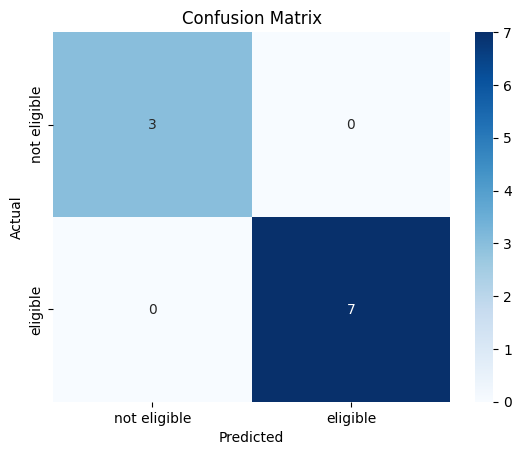

In [12]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['not eligible', 'eligible'],
            yticklabels=['not eligible', 'eligible'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

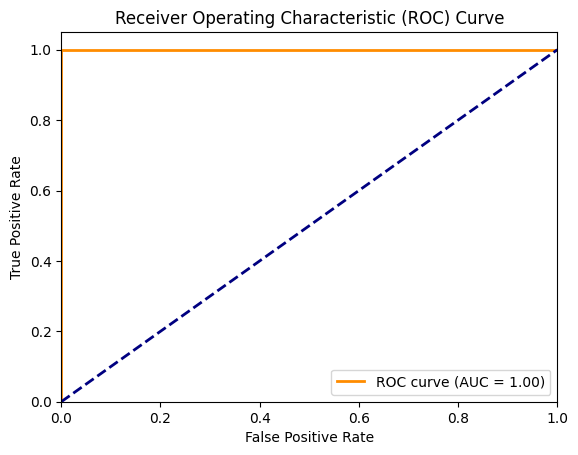

In [14]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()